## E-commerce-Sales- EDA Project

### Importando banco de dados

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sharmajicoder/e-commerce-sales-dataset")

print("Path to dataset files:", path)

c:\Users\lucas\anaconda\envs\datascience\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\lucas\anaconda\envs\datascience\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\lucas\.cache\kagglehub\datasets\sharmajicoder\e-commerce-sales-dataset\versions\1


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Listar arquivos disponíveis
files = os.listdir(path)
print("Arquivos disponíveis:", files)

# Carregando banco de dados
csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Fazendo cópia do DataFrame para manipulação
df1 = df.copy().reset_index(drop=True)
df1.shape
df1.head()

Arquivos disponíveis: ['amazon_sales_dataset.csv']


,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI


### Estudando o banco de dados

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  

In [5]:
# Convertendo colunas de data para o formato datetime
df1['order_date'] = pd.to_datetime(df1['order_date'])
df1['ship_date'] = pd.to_datetime(df1['ship_date'])
df1['delivery_date'] = pd.to_datetime(df1['delivery_date'])
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        10000 non-null  object        
 1   order_date      10000 non-null  datetime64[ns]
 2   ship_date       10000 non-null  datetime64[ns]
 3   delivery_date   10000 non-null  datetime64[ns]
 4   order_status    10000 non-null  object        
 5   customer_id     10000 non-null  object        
 6   customer_name   10000 non-null  object        
 7   country         10000 non-null  object        
 8   state           10000 non-null  object        
 9   city            10000 non-null  object        
 10  product_id      10000 non-null  object        
 11  product_name    10000 non-null  object        
 12  category        10000 non-null  object        
 13  sub_category    10000 non-null  object        
 14  brand           10000 non-null  object        
 15  qua

In [6]:
# Coletando os métodos de pagamento únicos
df1['payment_method'].unique()

array(['Card', 'COD', 'UPI', 'NetBanking'], dtype=object)

In [7]:
# Entendo o período do dataset
print(df1['delivery_date'].max())
print(df1['order_date'].min())

2026-02-10 00:00:00
2026-01-01 00:00:00


In [8]:
# Verificando as categorias disponíveis
df1['category'].unique()

array(['Home', 'Electronics', 'Fashion'], dtype=object)

In [9]:
df1['discount'].unique()

array([0.26, 0.24, 0.14, 0.06, 0.1 , 0.22, 0.19, 0.03, 0.12, 0.27, 0.3 ,
       0.02, 0.13, 0.25, 0.28, 0.21, 0.09, 0.2 , 0.16, 0.29, 0.04, 0.  ,
       0.07, 0.08, 0.17, 0.15, 0.11, 0.18, 0.05, 0.01, 0.23])

In [10]:
# Adicionando métricas de faturamento bruto, diferença absoluta e percentual de perda
df1['faturamento_bruto'] = df1['quantity'] * df1['unit_price']
df1['diferenca_absoluta'] = df1['faturamento_bruto'] - df1['total_sales']
df1['percentual_perda'] = (df1['diferenca_absoluta'] / df1['faturamento_bruto']) * 100

In [11]:
df1.head(3)

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method,faturamento_bruto,diferenca_absoluta,percentual_perda
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card,127403.37,33064.0262,25.952238
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD,72277.52,17233.6448,23.843714
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI,188595.72,26339.2908,13.966007


In [12]:
df1.drop(columns=['country'], inplace=True)

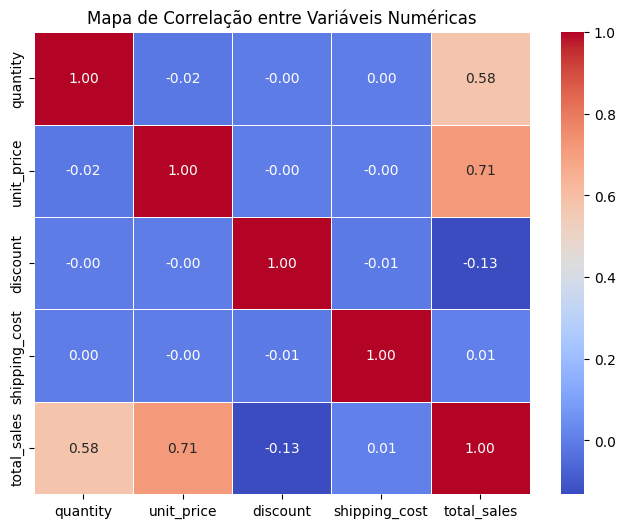

In [13]:
# Selecionando apenas colunas numéricas
numeric_cols = ['quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales']

# Criar matriz de correlação
corr_matrix = df[numeric_cols].corr()

# Plotar mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlação entre Variáveis Numéricas")
plt.show()


- Produtos que possuem o maior preçp unitário, tendem a gerar maior valor de vendas
- 

----

### 1. Health Check de Vendas: Concentração geográfica, métodos de pagamento e impacto dos descontos no faturamento.

1.1 Quais são as regiões que possuem a maior concentração dos clientes?

In [14]:
# Criando a tabela de concentração geográfica a partir do df1
concentracao_geo = df1.groupby('state').agg({
    'order_id': 'count',        # Quantidade de pedidos na região
    'total_sales': 'sum'        # Faturamento total na região
}).reset_index()

# Ordenando pelas regiões com maior quantidade de pedidos
concentracao_geo = concentracao_geo.sort_values(by='order_id', ascending=False)

# Renomeando as colunas para o relatório
concentracao_geo.columns = ['Estado', 'Qtd_Pedidos', 'Faturamento_Total']

# Adicionando a coluna de porcentagem formatada
total_pedidos = concentracao_geo['Qtd_Pedidos'].sum()
concentracao_geo['%_Pedidos'] = (
    (concentracao_geo['Qtd_Pedidos'] / total_pedidos) * 100
).round(2).astype(str) + '%'

# Exibindo as 10 primeiras linhas
concentracao_geo.head(10)


,Estado,Qtd_Pedidos,Faturamento_Total,%_Pedidos
2,Arizona,238,1.470989e+07,2.38%
7,Delaware,225,1.360749e+07,2.25%
32,North Carolina,224,1.503767e+07,2.24%
6,Connecticut,219,1.410674e+07,2.19%
3,Arkansas,213,1.420703e+07,2.13%
1,Alaska,212,1.371125e+07,2.12%
46,Washington,212,1.408091e+07,2.12%
33,North Dakota,212,1.434795e+07,2.12%
31,New York,212,1.292270e+07,2.12%
11,Idaho,211,1.390459e+07,2.11%


1.1.2 Quais são os 10 estados com maior receita líquida?

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\2764655724.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucratividade_regional.head(10),


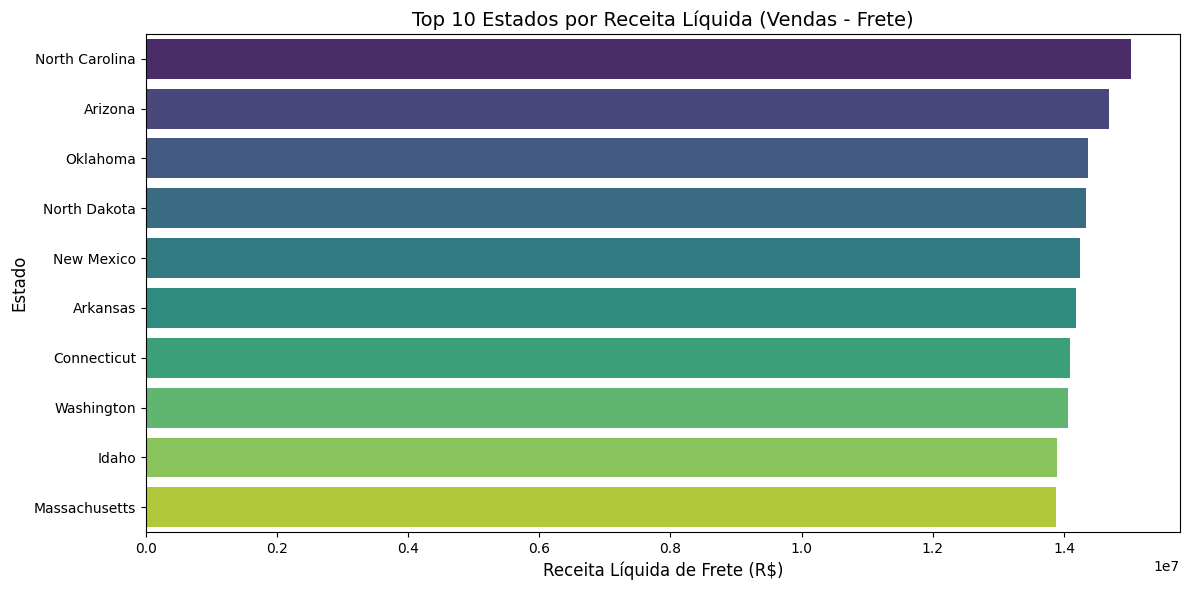

,state,receita_liquida_frete,total_sales,shipping_cost
0,North Carolina,1.501816e+07,1.503767e+07,19512.32
1,Arizona,1.468970e+07,1.470989e+07,20185.67
2,Oklahoma,1.435925e+07,1.437737e+07,18128.93
3,North Dakota,1.433035e+07,1.434795e+07,17602.94
4,New Mexico,1.423756e+07,1.425520e+07,17639.36
5,Arkansas,1.418900e+07,1.420703e+07,18029.97
6,Connecticut,1.408758e+07,1.410674e+07,19162.49
7,Washington,1.406262e+07,1.408091e+07,18287.47
8,Idaho,1.388704e+07,1.390459e+07,17551.70
9,Massachusetts,1.387156e+07,1.388731e+07,15752.52


In [15]:
# 1. Calcular a Receita Líquida de Frete no df1
df1['receita_liquida_frete'] = df1['total_sales'] - df1['shipping_cost']

# 2. Agrupar por estado
lucratividade_regional = df1.groupby('state').agg({
    'receita_liquida_frete': 'sum',
    'total_sales': 'sum',
    'shipping_cost': 'sum'
}).sort_values(by='receita_liquida_frete', ascending=False).reset_index()

# 3. Visualização em Gráfico de Barras
plt.figure(figsize=(12, 6))
sns.barplot(data=lucratividade_regional.head(10), 
            x='receita_liquida_frete', 
            y='state', 
            palette='viridis')

plt.title('Top 10 Estados por Receita Líquida (Vendas - Frete)', fontsize=14)
plt.xlabel('Receita Líquida de Frete (R$)', fontsize=12)
plt.ylabel('Estado', fontsize=12)

plt.tight_layout()
plt.show()

# Exibir a tabela para precisão numérica
lucratividade_regional.head(10)


1.2 Qual é a categoria de produtos que possu o maior volume de pedidos?

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\1769744356.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='quantity', data=sales_by_category, palette='viridis')


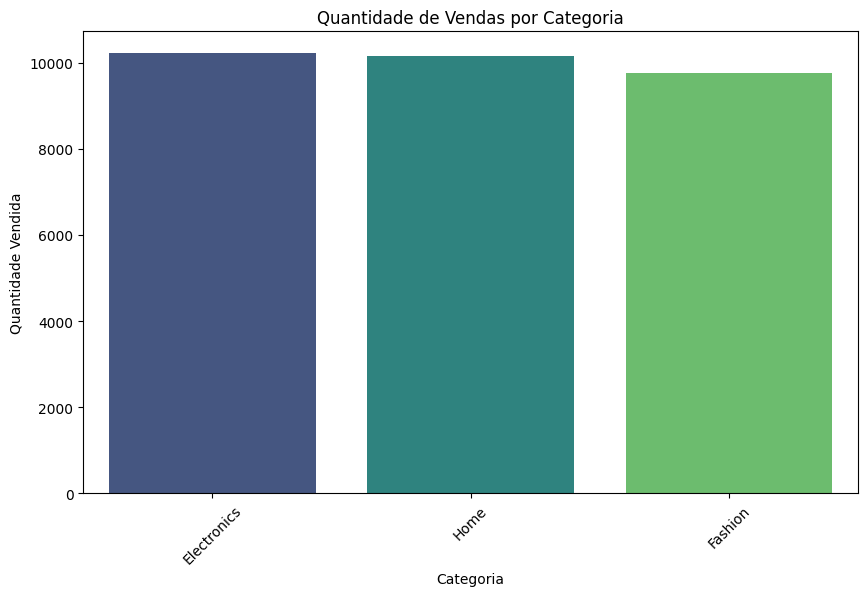

In [16]:
# Agrupar vendas por categoria
sales_by_category = df1.groupby('category')['quantity'].sum().reset_index()

# Ordenar para facilitar a leitura
sales_by_category = sales_by_category.sort_values(by='quantity', ascending=False)

# Plotar gráfico de barras verticais
plt.figure(figsize=(10,6))
sns.barplot(x='category', y='quantity', data=sales_by_category, palette='viridis')

plt.title("Quantidade de Vendas por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45)
plt.show()


- Vendas x Sub Categoria

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\3868932320.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='sub_category', x='quantity', data=sales_by_category, palette='viridis')


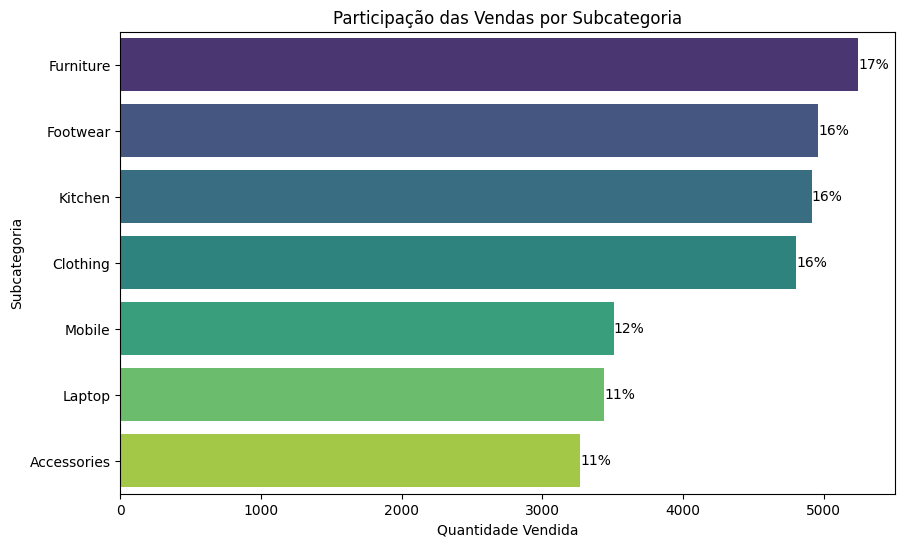

In [17]:
# Agrupar vendas por categoria
sales_by_category = df1.groupby('sub_category')['quantity'].sum().reset_index()

# Ordenar para facilitar a leitura
sales_by_category = sales_by_category.sort_values(by='quantity', ascending=False)

# Calcular porcentagem
total_quantity = sales_by_category['quantity'].sum()
sales_by_category['%_Vendas'] = (
    (sales_by_category['quantity'] / total_quantity) * 100
).round().astype(int).astype(str) + '%'

# Plotar gráfico de barras horizontais
plt.figure(figsize=(10,6))
sns.barplot(y='sub_category', x='quantity', data=sales_by_category, palette='viridis')

plt.title("Participação das Vendas por Subcategoria")
plt.xlabel("Quantidade Vendida")
plt.ylabel("Subcategoria")

# Adicionar os valores de porcentagem ao lado das barras
for index, value in enumerate(sales_by_category['quantity']):
    plt.text(value, index, sales_by_category['%_Vendas'].iloc[index], va='center')

plt.show()


1.3 Qual é o impacto que os descontos estão fazendo no volume de vendas? Será que realmente os descontos realmente estão convertendo vendas?

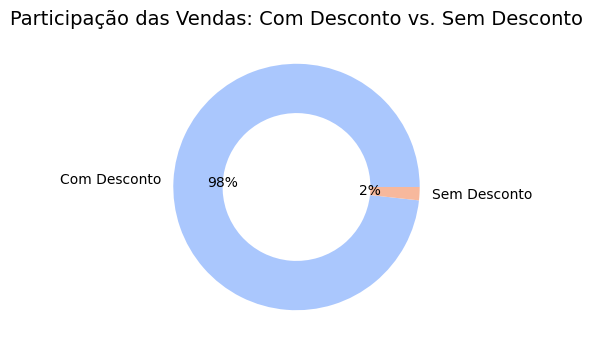

In [18]:
# Criando uma coluna temporária para identificar se houve desconto
df1['tem_desconto'] = df1['discount'].apply(lambda x: 'Com Desconto' if x > 0 else 'Sem Desconto')

# Agrupando para ver o total absoluto de quantidade
vendas_por_desconto = df1.groupby('tem_desconto')['quantity'].sum().reset_index()

# Calcular porcentagem
total_quantity = vendas_por_desconto['quantity'].sum()
vendas_por_desconto['%_Vendas'] = (
    (vendas_por_desconto['quantity'] / total_quantity) * 100
).round().astype(int).astype(str) + '%'

# Gráfico de rosca (donut chart)
plt.figure(figsize=(6, 4))
plt.pie(
    vendas_por_desconto['quantity'],
    labels=vendas_por_desconto['tem_desconto'],
    autopct=lambda p: f'{int(round(p))}%',  # mostra porcentagem formatada
    colors=sns.color_palette('coolwarm', len(vendas_por_desconto)),
    wedgeprops={'width':0.4}  # transforma em rosca
)

plt.title('Participação das Vendas: Com Desconto vs. Sem Desconto', fontsize=14)
plt.show()


1.4 Quais categorias/subcategorias que mais são afetadas por ofertas de desconto?

In [19]:
# Agrupando por Categoria e Subcategoria para analisar os descontos
analise_desconto = df1.groupby(['category', 'sub_category']).agg({
    'discount': ['mean', 'sum'],       # Média e Total de desconto
    'quantity': 'sum',                 # Volume de vendas
    'total_sales': 'sum'               # Faturamento líquido
}).reset_index()

# Ajustando o nome das colunas para facilitar a leitura
analise_desconto.columns = [
    'Categoria', 'Subcategoria', 'Media_Desconto', 
    'Total_Desconto_Valor', 'Qtd_Vendida', 'Faturamento_Liquido'
]

# Ordenando pelas subcategorias que tiveram maior valor total de desconto
analise_desconto = analise_desconto.sort_values(by='Total_Desconto_Valor', ascending=False)

# Define o formato de exibição para duas casas decimais
pd.options.display.float_format = '{:.2f}'.format

print("--- Análise de Descontos por Categoria e Subcategoria ---")
print(f"Média geral de desconto: {df1['discount'].mean():.2f}%")
analise_desconto

--- Análise de Descontos por Categoria e Subcategoria ---
Média geral de desconto: 0.15%


,Categoria,Subcategoria,Media_Desconto,Total_Desconto_Valor,Qtd_Vendida,Faturamento_Liquido
5,Home,Furniture,0.15,261.56,5247,111843677.98
4,Fashion,Footwear,0.15,254.40,4962,104005232.00
6,Home,Kitchen,0.15,243.90,4914,102920088.08
3,Fashion,Clothing,0.15,233.32,4806,104003832.75
2,Electronics,Mobile,0.15,174.56,3508,74281306.95
1,Electronics,Laptop,0.15,166.49,3439,74661262.80
0,Electronics,Accessories,0.15,165.45,3268,70413704.99


1.5 Quais são os métodos de pagamentos mais utilizados pelos clientes?

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\3080608300.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pagamentos, x='Metodo', y='Qtd_Pedidos', palette='viridis')


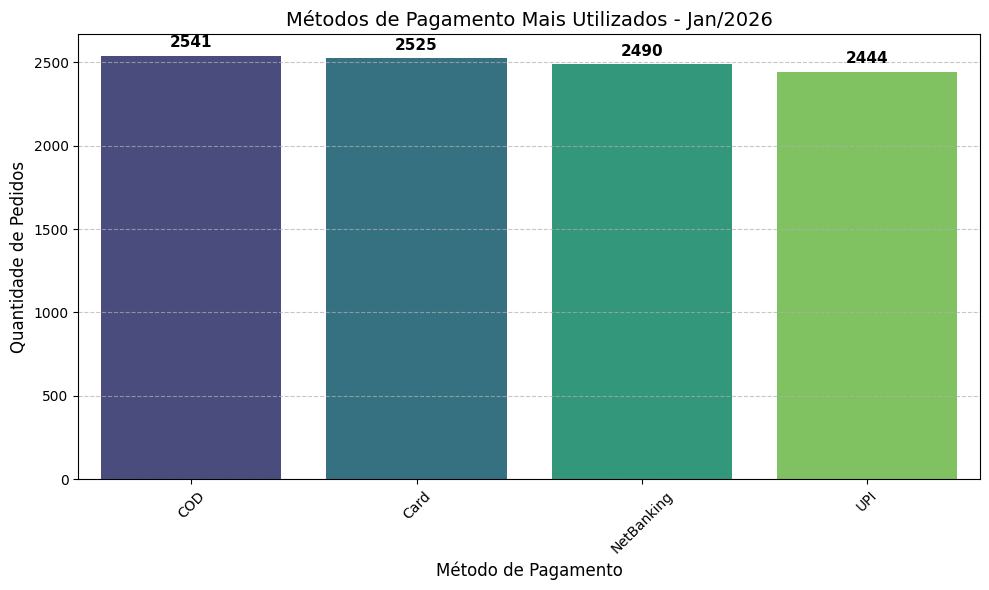

In [20]:
# Agrupando a contagem de pedidos por método de pagamento
pagamentos = df1['payment_method'].value_counts().reset_index()
pagamentos.columns = ['Metodo', 'Qtd_Pedidos']

plt.figure(figsize=(10, 6))

# Criando o gráfico de barras verticais
sns.barplot(data=pagamentos, x='Metodo', y='Qtd_Pedidos', palette='viridis')

# Adicionando rótulos de dados nas barras para precisão
for i, valor in enumerate(pagamentos['Qtd_Pedidos']):
    plt.text(i, valor + 50, f'{valor}', ha='center', fontsize=11, fontweight='bold')

plt.title('Métodos de Pagamento Mais Utilizados - Jan/2026', fontsize=14)
plt.xlabel('Método de Pagamento', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.xticks(rotation=45) # Inclina os nomes para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1.6 Há relação entre o método de pagamento e o tipo de produto que os clientes compram?

--- Frequência: Categoria vs. Método de Pagamento ---
payment_method  COD  Card  NetBanking  UPI
category                                  
Electronics     849   871         831  801
Fashion         821   854         811  783
Home            871   800         848  860


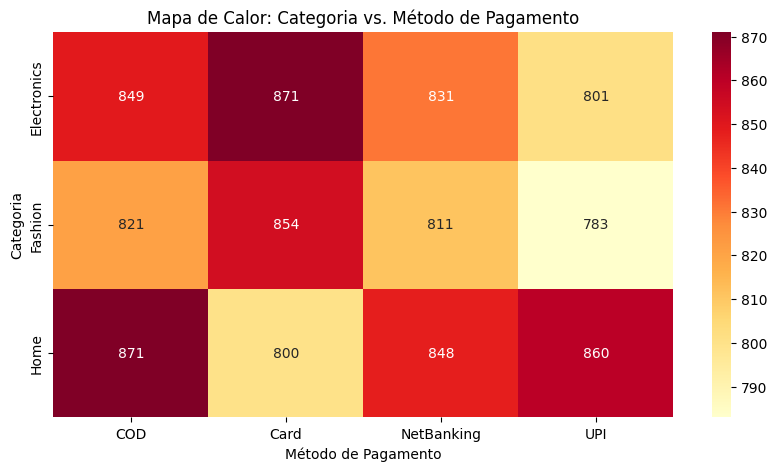

In [21]:
# Criando a tabela cruzada (Crosstab)
tabela_cruzada = pd.crosstab(df1['category'], df1['payment_method'])

# Exibindo a tabela formatada
print('--- Frequência: Categoria vs. Método de Pagamento ---')
print(tabela_cruzada)

# Visualizando como um Heatmap com cores mais quentes
plt.figure(figsize=(10, 5))
sns.heatmap(tabela_cruzada, annot=True, fmt='d', cmap='YlOrRd')  # paleta quente
plt.title('Mapa de Calor: Categoria vs. Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Categoria')
plt.show()


1.7 Em quais dias da semana há maior volume de vendas?

1.7.1 Volume de Vendas por Dia da Semana

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\806840298.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendas_dia_semana, x='Dia_da_Semana', y='Qtd_Pedidos', palette='Blues_d')


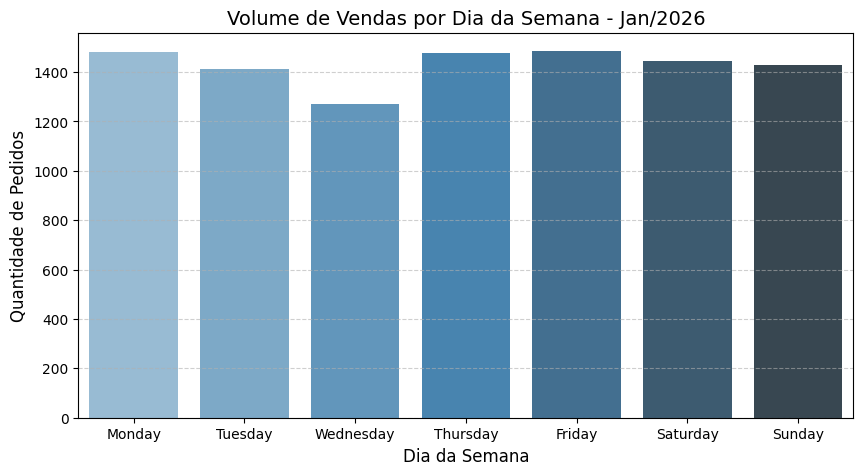

In [22]:
# Garantir que a coluna de data está no formato correto e extrair o dia da semana
df1['day_of_week'] = df1['order_date'].dt.day_name()

# Ordenar os dias para o gráfico não ficar bagunçado
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Agrupando os dados
vendas_dia_semana = df1['day_of_week'].value_counts().reindex(dias_ordenados).reset_index()
vendas_dia_semana.columns = ['Dia_da_Semana', 'Qtd_Pedidos']

plt.figure(figsize=(10, 5))
sns.barplot(data=vendas_dia_semana, x='Dia_da_Semana', y='Qtd_Pedidos', palette='Blues_d')

plt.title('Volume de Vendas por Dia da Semana - Jan/2026', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

1.7.2 Comparativo: 1ª Quinzena vs. 2ª Quinzena

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\759706259.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_quinzena, x='quinzena', y='total_sales', palette='Set2')


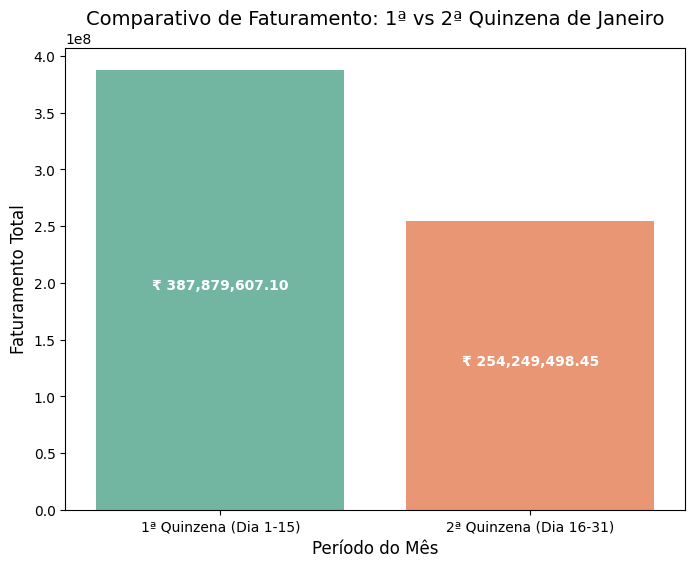

In [23]:
# Criando a regra para as quinzenas
df1['quinzena'] = df1['order_date'].dt.day.apply(lambda x: '1ª Quinzena (Dia 1-15)' if x <= 15 else '2ª Quinzena (Dia 16-31)')

# Agrupando por faturamento
faturamento_quinzena = df1.groupby('quinzena')['total_sales'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=faturamento_quinzena, x='quinzena', y='total_sales', palette='Set2')

# Formatação de valores para o storytelling
for i, valor in enumerate(faturamento_quinzena['total_sales']):
    plt.text(i, valor/2, f'₹ {valor:,.2f}', ha='center', color='white', fontweight='bold')

plt.title('Comparativo de Faturamento: 1ª vs 2ª Quinzena de Janeiro', fontsize=14)
plt.xlabel('Período do Mês', fontsize=12)
plt.ylabel('Faturamento Total', fontsize=12)

plt.show()

1.8 Quantos clientes compraram mais de uma vez? Dentre esses clientes, qual é a média de frequência?

- Métricas de Retenção e Frequência

In [24]:
# 1. Agrupando por cliente para ver o comportamento individual
comportamento_cliente = df1.groupby('customer_id').agg({
    'order_id': 'count',
    'total_sales': 'sum'
}).reset_index()

# 2. Identificando recorrentes (pedidos > 1)
clientes_recorrentes = comportamento_cliente[comportamento_cliente['order_id'] > 1]

# 3. Criando a tabela de resumo
resumo_fidelidade = pd.DataFrame({
    'Métrica': [
        'Total de Clientes Únicos', 
        'Clientes que compraram + de uma vez', 
        'Percentual de Retenção (%)',
        'Média de Frequência (Recorrentes)',
        'Ticket Médio por Cliente (Geral)'
    ],
    'Valor': [
        comportamento_cliente['customer_id'].nunique(),
        len(clientes_recorrentes),
        (len(clientes_recorrentes) / comportamento_cliente['customer_id'].nunique()) * 100,
        clientes_recorrentes['order_id'].mean(),
        comportamento_cliente['total_sales'].mean()
    ]
})

pd.options.display.float_format = '{:.2f}'.format
print("--- Tabela de Retenção e Valor do Cliente ---")
resumo_fidelidade

--- Tabela de Retenção e Valor do Cliente ---


,Métrica,Valor
0,Total de Clientes Únicos,6016.00
1,Clientes que compraram + de uma vez,2780.00
2,Percentual de Retenção (%),46.21
3,Média de Frequência (Recorrentes),2.43
4,Ticket Médio por Cliente (Geral),106736.89


Conclusão:

1. Os dados revelam uma dependência estratégica bem-sucedida, porém acentuada, de incentivos promocionais. Em um cenário sazonalmente desafiador (pós-festas), a política de descontos com margem de 15% sustentou a operação, atingindo 98% dasas vendas totais durante o mês de Janeiro. Além disso, nota-se uma correlação direta entre o volume transacional e a primeira quinzena do mês, sugerindo que a antecipação de ofertas alinhada ao ciclo de liquidez (salários) dos consumidores foi o principal motor de conversão em Janeiro.

----

### 2. Eficiência Logística : Onde a entrega é mais rápida? Onde o frete é abusivo?

In [25]:
# Criando o DataFrame focado em Logística
df_logistic = df1[[
    'order_id', 'order_date', 'ship_date', 'delivery_date',
    'state', 'city', 'product_name', 'category', 'sub_category',
    'brand', 'unit_price', 'shipping_cost', 'total_sales'
]].copy()

# Calcular tempos sem sobrescrever datas
df_logistic['dispatch_time'] = (df_logistic['ship_date'] - df_logistic['order_date']).dt.days # Tempo entre pedido e envio
df_logistic['delivery_time'] = (df_logistic['delivery_date'] - df_logistic['ship_date']).dt.days # Tempo entre envio e entrega
df_logistic['lead_time'] = (df_logistic['delivery_date'] - df_logistic['order_date']).dt.days # Tempo total entre pedido e entrega

# Filtrar apenas registros válidos (sem tempos negativos)
df_logistic = df_logistic[
    (df_logistic['dispatch_time'] >= 0) &
    (df_logistic['delivery_time'] >= 0)
]

# Métrica de impacto de custo (Frete sobre Venda)
df_logistic['shipping_impact_%'] = (df_logistic['shipping_cost'] / df_logistic['total_sales']) * 100

# Conferir primeiras linhas
df_logistic.head(5)


,order_id,order_date,ship_date,delivery_date,state,city,product_name,category,sub_category,brand,unit_price,shipping_cost,total_sales,dispatch_time,delivery_time,lead_time,shipping_impact_%
1,A10001,2026-01-20,2026-02-03,2026-02-03,Tennessee,Madisonmouth,school,Home,Furniture,Davis LLC,36138.76,112.96,55043.88,14,0,14,0.21
6,A10006,2026-01-04,2026-01-10,2026-01-21,Colorado,Turnerville,page,Electronics,Mobile,Wade-Jackson,41577.60,29.90,156361.68,6,11,17,0.02
9,A10009,2026-01-24,2026-01-26,2026-02-10,South Carolina,Kendraton,example,Fashion,Clothing,"Carroll, Barnes and Harris",42438.49,144.57,74836.31,2,15,17,0.19
11,A10011,2026-01-17,2026-01-17,2026-02-06,Georgia,Lawrenceland,experience,Home,Furniture,Johns and Sons,5542.35,57.50,15576.08,0,20,20,0.37
13,A10013,2026-01-02,2026-01-06,2026-01-10,California,South Heather,series,Electronics,Accessories,Monroe PLC,2200.82,120.87,3950.30,4,4,8,3.06


In [26]:
df_logistic.shape

(1752, 17)

In [27]:
df_logistic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1752 entries, 1 to 9998
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           1752 non-null   object        
 1   order_date         1752 non-null   datetime64[ns]
 2   ship_date          1752 non-null   datetime64[ns]
 3   delivery_date      1752 non-null   datetime64[ns]
 4   state              1752 non-null   object        
 5   city               1752 non-null   object        
 6   product_name       1752 non-null   object        
 7   category           1752 non-null   object        
 8   sub_category       1752 non-null   object        
 9   brand              1752 non-null   object        
 10  unit_price         1752 non-null   float64       
 11  shipping_cost      1752 non-null   float64       
 12  total_sales        1752 non-null   float64       
 13  dispatch_time      1752 non-null   int64         
 14  delivery_time

----

**2.1 Análise de Custo**

- Quais produtos que possuem o maior custo de envio?

In [28]:
# 1. Agrupando por produto para calcular o custo médio de envio
top_frete_produtos = df_logistic.groupby('product_name')['shipping_cost'].mean().sort_values(ascending=False).head(10).reset_index()

# Exibindo a tabela para conferência
top_frete_produtos

,product_name,shipping_cost
0,less,149.48
1,where,149.34
2,this,149.11
3,energy,148.27
4,like,147.71
5,year,147.34
6,research,147.30
7,responsibility,146.60
8,condition,146.01
9,apply,145.83


- Quais subcategorias são mais afetadas pelo preço do frete?

In [29]:
# Agrupar por subcategoria e calcular a média do impacto
impacto_subcat = (
    df_logistic.groupby('sub_category')['shipping_impact_%']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .round(2)
)

# Criar coluna formatada em porcentagem
impacto_subcat['shipping_impact_%'] = (
    impacto_subcat['shipping_impact_%'].round(2).astype(str) + '%'
)

# Exibir tabela
impacto_subcat


,sub_category,shipping_impact_%
0,Accessories,0.75%
1,Laptop,0.66%
2,Footwear,0.6%
3,Kitchen,0.54%
4,Clothing,0.47%
5,Furniture,0.43%
6,Mobile,0.4%


- Calcular o impacto do valor do frete sobre o faturamento total. Quais regiões (States/Cities) têm o frete mais caro proporcionalmente?

- Calcular o impacto do valor do frete sobre o faturamento total
Por que? No e-commerce, se o frete custa mais que 15-20% do produto, a operação pode estar perdendo dinheiro. Quais regiões (States/Cities) têm o frete mais caro proporcionalmente? Isso é um insight de logística puro.

In [30]:
# 1. Agrupando por Estado e Cidade para ver o impacto médio
frete_proporcional = df_logistic.groupby(['state', 'city']).agg({
    'shipping_impact_%': 'mean',
    'total_sales': 'sum',
    'shipping_cost': 'sum',
}).reset_index()

# 2. Filtrando apenas regiões com impacto crítico (acima de 20%)
regioes_criticas = frete_proporcional[frete_proporcional['shipping_impact_%'] > 20].sort_values(by='shipping_impact_%', ascending=False)

# 3. Formatando a coluna de porcentagem
regioes_criticas['send_impact'] = (
    regioes_criticas['shipping_impact_%'].round().astype(int).astype(str) + '%'
)

# 4. Exibindo tabela formatada
pd.options.display.float_format = '{:.2f}'.format
print("--- Regiões com Frete Crítico (> 20% do valor da venda) ---")
regioes_criticas[['state', 'city', 'send_impact', 'total_sales', 'shipping_cost']].head(15).reset_index(drop=True)

--- Regiões com Frete Crítico (> 20% do valor da venda) ---


,state,city,send_impact,total_sales,shipping_cost
0,Oregon,Port Nancy,35%,357.79,126.07
1,Idaho,Freemanton,25%,411.51,104.44
2,Nevada,Jeffreyview,23%,555.71,126.99
3,New Mexico,Kellyville,23%,388.38,88.39
4,Tennessee,South Aaron,21%,585.79,125.76
5,North Carolina,Cherylborough,21%,701.04,145.65


----

**2.2 Análise de Lead Time / Produtividade**

- Qual é o leadtime médio geral para o envio dos produtos? 

In [31]:
print(f"Tempo médio de lead time: {df_logistic['lead_time'].mean():.2f} dias")
print(f"Tempo médio de despacho: {df_logistic['dispatch_time'].mean():.2f} dias")
print(f"Tempo médio de entrega: {df_logistic['delivery_time'].mean():.2f} dias")


Tempo médio de lead time: 20.04 dias
Tempo médio de despacho: 9.88 dias
Tempo médio de entrega: 10.16 dias


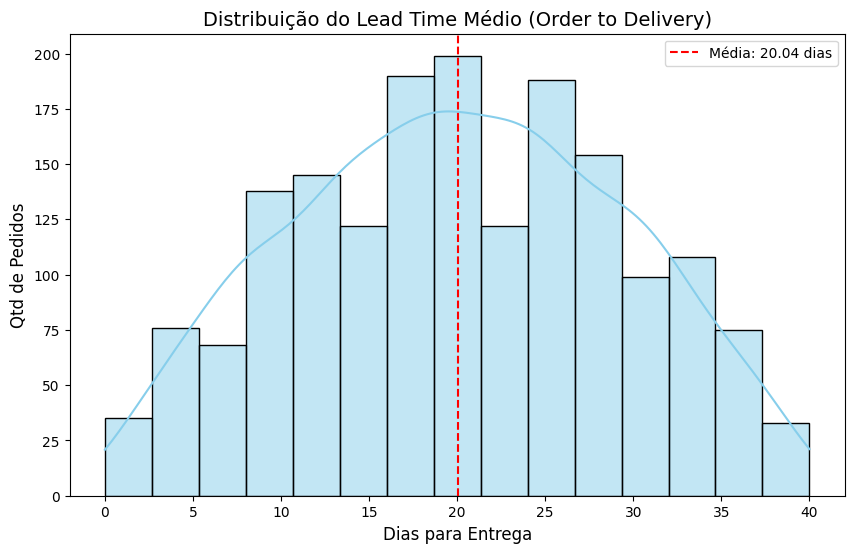

O tempo médio geral de entrega em Janeiro/2026 foi de 20.04 dias.


In [32]:
plt.figure(figsize=(10, 6))

# Gerando o histograma do tempo de entrega real
sns.histplot(df_logistic['lead_time'], bins=15, kde=True, color='skyblue')

# Adicionando linha de média geral
media_geral = df_logistic['lead_time'].mean()
plt.axvline(media_geral, color='red', linestyle='--', label=f'Média: {media_geral:.2f} dias')

plt.title('Distribuição do Lead Time Médio (Order to Delivery)', fontsize=14)
plt.xlabel('Dias para Entrega', fontsize=12)
plt.ylabel('Qtd de Pedidos', fontsize=12)
plt.legend()

plt.show()

print(f"O tempo médio geral de entrega em Janeiro/2026 foi de {media_geral:.2f} dias.")

- Qual é o tempo médio geral para o leadtime por categoria e subcategoria?

In [33]:
lead_time_df = df_logistic.groupby(['category','sub_category']).agg({
    'dispatch_time': 'mean',
    'delivery_time': 'mean',
    'lead_time': 'mean'
}).reset_index()
lead_time_df.head(5)

print("--- Lead Time por Categoria e Subcategoria ---")
lead_time_df.sort_values(by='lead_time', ascending=False).head(10).reset_index(drop=True)

--- Lead Time por Categoria e Subcategoria ---


,category,sub_category,dispatch_time,delivery_time,lead_time
0,Electronics,Mobile,10.77,9.95,20.73
1,Electronics,Laptop,9.02,11.23,20.25
2,Fashion,Footwear,10.06,10.07,20.13
3,Home,Kitchen,9.63,10.40,20.03
4,Fashion,Clothing,10.45,9.53,19.98
5,Electronics,Accessories,10.12,9.69,19.81
6,Home,Furniture,9.27,10.20,19.47


- Quais são os estados que possuem a maior lead time? 

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\3443652464.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


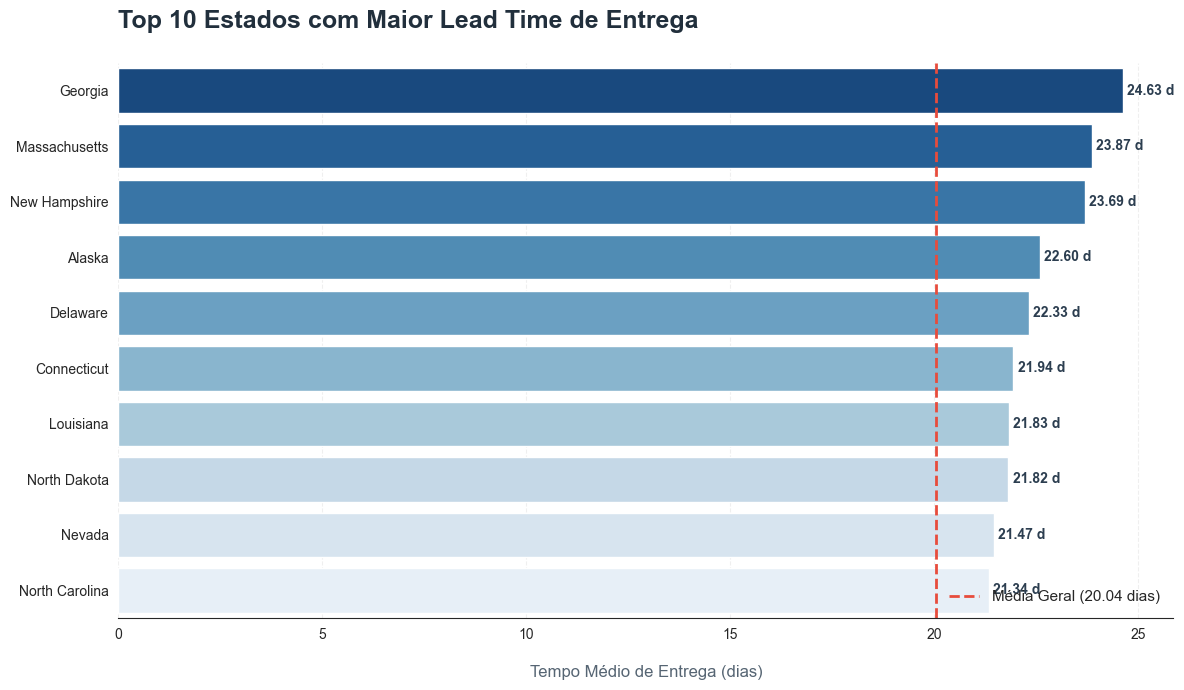

In [34]:
# 1. Calcular tempo médio por estado (usando o lead_time conforme solicitado)
media_por_estado = (
    df_logistic.groupby('state')['lead_time']
    .mean()
    .reset_index()
    .sort_values(by='lead_time', ascending=False)
)

# 2. Selecionar apenas o Top 10 estados com maiores tempos
top10_estados = media_por_estado.head(10)

# 3. Calcular tempo médio geral da base completa (Linha de Referência)
tempo_medio_geral = df_logistic['lead_time'].mean()

# 4. Criar a visualização
sns.set_style("white")
plt.figure(figsize=(12, 7))

# Gráfico de barras horizontais (melhor para ler nomes de estados)
paleta_gradiente = sns.color_palette("Blues_r", n_colors=10)

plot = sns.barplot(
    data=top10_estados,
    x='lead_time',
    y='state',
    palette=paleta_gradiente
)

# 5. Adicionar linha vertical com tempo médio geral
plt.axvline(
    tempo_medio_geral, 
    color='#E74C3C', 
    linestyle='--', 
    linewidth=2,
    label=f'Média Geral ({tempo_medio_geral:.2f} dias)'
)

# 6. Rótulos de dados nas pontas das barras para facilitar a leitura rápida
for i, valor in enumerate(top10_estados['lead_time']):
    plt.text(valor + 0.1, i, f'{valor:.2f} d', va='center', fontsize=10, fontweight='bold', color='#2C3E50')

# 7. Customização Executiva
plt.title('Top 10 Estados com Maior Lead Time de Entrega\n', fontsize=18, fontweight='bold', loc='left', color='#212F3C')
plt.xlabel('\nTempo Médio de Entrega (dias)', fontsize=12, color='#566573')
plt.ylabel('', fontsize=12)

# Legenda na parte inferior
plt.legend(loc='lower right', frameon=False, fontsize=11)

# Remoção de bordas e ajuste de grid
sns.despine(left=True, bottom=False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Top 10 Estados com maior lead time por categoria

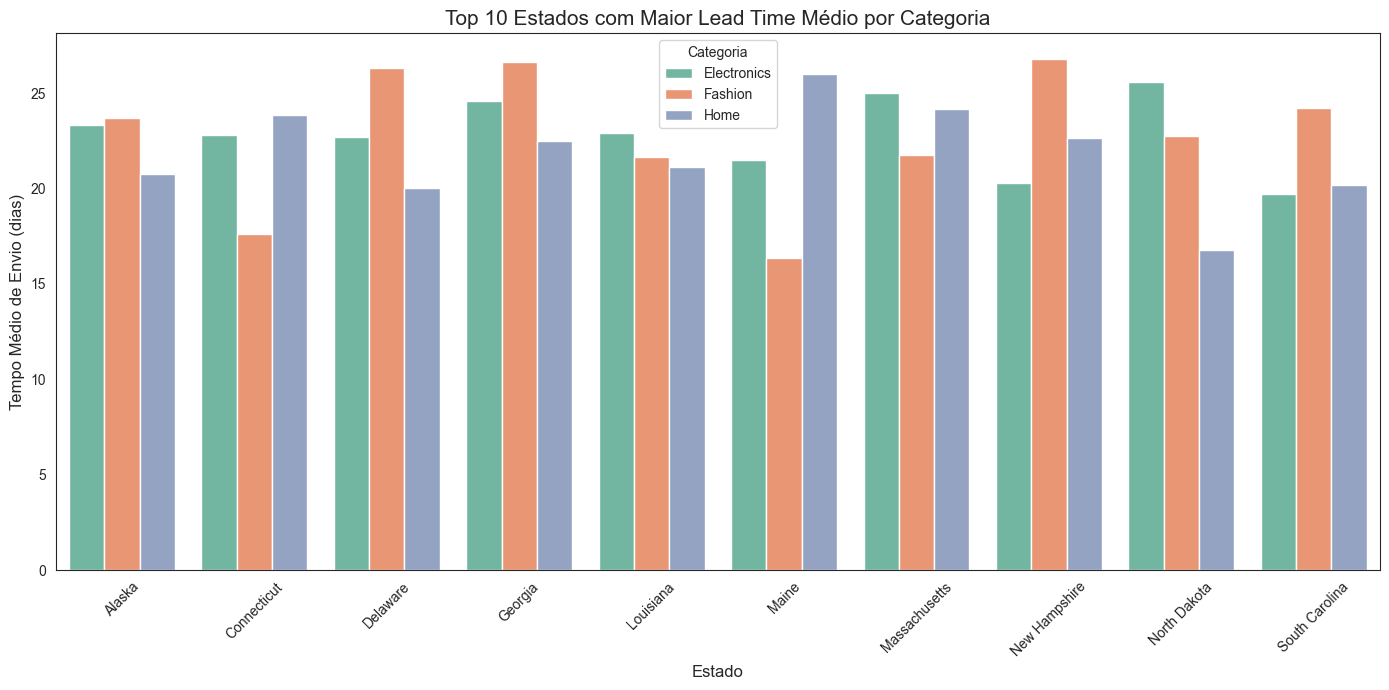

In [35]:
# Agrupando por estado e categoria, calculando tempo médio de envio
tempo_envio_regiao_categoria = (
    df_logistic.groupby(['state', 'category'])['lead_time']
    .mean()
    .reset_index()
)

# Selecionar apenas os Top 10 estados com maior tempo médio de envio
top_10_estados = (
    tempo_envio_regiao_categoria.groupby('state')['lead_time']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Filtrar os dados originais para manter apenas os estados do Top 10
dados_top_10 = tempo_envio_regiao_categoria[
    tempo_envio_regiao_categoria['state'].isin(top_10_estados['state'])
]

# Criando o gráfico
plt.figure(figsize=(14, 7))
sns.barplot(
    data=dados_top_10,
    x='state',
    y='lead_time',
    hue='category',
    palette='Set2'
)

# Customização
plt.title('Top 10 Estados com Maior Lead Time Médio por Categoria', fontsize=15)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Tempo Médio de Envio (dias)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Categoria')

plt.tight_layout()
plt.show()



- leadtime x marca

In [36]:
lead_time_brand = df_logistic.groupby('brand').agg({
    'dispatch_time': 'mean',
    'delivery_time': 'mean',
    'lead_time': 'mean'
    }).reset_index()

print("--- Lead Time por Marca ---")

lead_time_brand['lead_time'] = lead_time_brand['lead_time'].round(2)
lead_time_brand.sort_values(by='lead_time', ascending=False).head(10).reset_index(drop=True)

--- Lead Time por Marca ---


,brand,dispatch_time,delivery_time,lead_time
0,Elliott-Norris,5.00,35.00,40.00
1,Holland Inc,17.00,23.00,40.00
2,Sanders-Thomas,9.00,31.00,40.00
3,Turner and Sons,5.00,35.00,40.00
4,"Walsh, Pierce and Haynes",14.00,26.00,40.00
5,"Klein, Brooks and Boone",32.00,7.00,39.00
6,"Johnson, Ryan and Jones",35.00,4.00,39.00
7,Knight Group,24.00,15.00,39.00
8,"Jones, Miller and Thompson",4.00,35.00,39.00
9,Padilla-Contreras,8.00,31.00,39.00


- Quantos envios foram feitos fora do tempo médio para cada região?

In [37]:
lead_time_state = df_logistic.groupby('state').agg({
    'dispatch_time': 'mean',
    'delivery_time': 'mean',
    'lead_time': 'mean'
}).reset_index()
lead_time_df = lead_time_state.copy()
lead_time_df.head(5)

print("--- Lead Time por Estado ---")
lead_time_state.sort_values(by='lead_time', ascending=False).head(10).reset_index(drop=True)

--- Lead Time por Estado ---


,state,dispatch_time,delivery_time,lead_time
0,Georgia,11.37,13.26,24.63
1,Massachusetts,12.29,11.58,23.87
2,New Hampshire,12.83,10.86,23.69
3,Alaska,13.05,9.55,22.60
4,Delaware,8.63,13.70,22.33
5,Connecticut,9.88,12.06,21.94
6,Louisiana,12.08,9.75,21.83
7,North Dakota,8.15,13.67,21.82
8,Nevada,11.65,9.82,21.47
9,North Carolina,12.08,9.26,21.34


**Estudando produtos que foram enviados com o tempo médio acima do médio**

- Quantos envios foram feitos fora do tempo médio para cada região?

In [38]:
# Calcular tempo médio por região (exemplo: por estado)
media_por_estado = df_logistic.groupby('state')['lead_time'].mean().reset_index()
media_por_estado.columns = ['state', 'tempo_medio_estado']

# Juntar a média de cada estado de volta ao df_logistic
df_logistic = df_logistic.merge(media_por_estado, on='state', how='left')

# Criar coluna indicando se o envio foi fora do tempo médio
df_logistic['fora_do_tempo_medio'] = df_logistic['lead_time'] > df_logistic['tempo_medio_estado']

# Contar quantos envios foram fora do tempo médio por estado
envios_fora = (
    df_logistic.groupby('state')['fora_do_tempo_medio']
    .sum()
    .reset_index()
    .sort_values(by='fora_do_tempo_medio', ascending=False)
)

# Renomear coluna
envios_fora.columns = ['Estado', 'Envios_Fora_do_Tempo_Médio']

print("--- TOP 10 Estados com envios Fora do Tempo Médio ---")
envios_fora.head(10) 


--- TOP 10 Estados com envios Fora do Tempo Médio ---


,Estado,Envios_Fora_do_Tempo_Médio
7,Delaware,27
11,Idaho,26
30,New Mexico,24
8,Florida,22
32,North Carolina,22
49,Wyoming,22
47,West Virginia,22
1,Alaska,21
15,Kansas,21
6,Connecticut,20


In [39]:
df_logistic['fora_do_tempo_medio'].value_counts()

fora_do_tempo_medio
True     879
False    873
Name: count, dtype: int64

In [40]:
df_fora = df_logistic.groupby('state')['fora_do_tempo_medio'].sum().reset_index()
df_fora['fora_do_tempo_medio'].sum()

np.int64(879)

C:\Users\lucas\AppData\Local\Temp\ipykernel_22196\4067595072.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


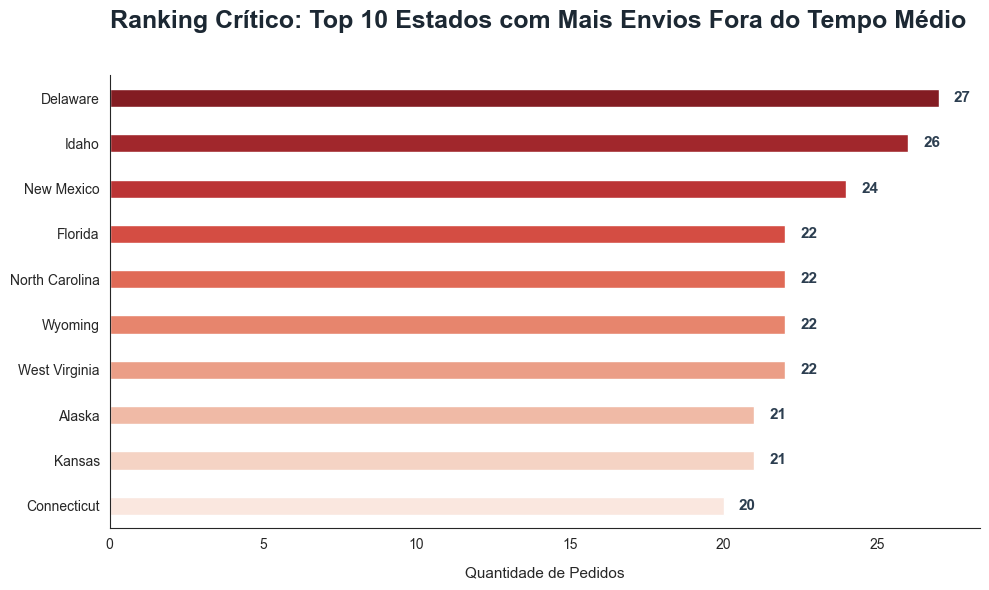

In [41]:
# 1. Preparação dos Dados
top_10_fora_tempo = (
    df_logistic[df_logistic['fora_do_tempo_medio'] == True] # Filtrando os atrasos
    .groupby('state')
    .size()
    .reset_index(name='qtd_pedidos')
    .sort_values(by='qtd_pedidos', ascending=False) # Maior valor primeiro
    .head(10)
)

# 2. Configuração do Estilo
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))

# Paleta "Reds_r" (O '_r' inverte: do mais escuro para o mais claro)
paleta_gradiente = sns.color_palette("Reds_r", n_colors=10)

# 3. Plotagem das Barras Horizontais
sns.barplot(
    data=top_10_fora_tempo, 
    x='qtd_pedidos', 
    y='state', 
    palette=paleta_gradiente,
    width=0.4, 
    ax=ax
)

# 4. Rótulos de Dados
for i, valor in enumerate(top_10_fora_tempo['qtd_pedidos']):
    ax.text(valor + 0.5, i, f'{valor}', ha='left', va='center', 
            fontweight='bold', color='#2C3E50', fontsize=11)

# 5. Refinamentos Finais
ax.set_title('Ranking Crítico: Top 10 Estados com Mais Envios Fora do Tempo Médio\n', 
             fontsize=18, fontweight='bold', loc='left', color='#1C2833', pad=15)

ax.set_xlabel('Quantidade de Pedidos', fontsize=11, labelpad=10 )
ax.set_ylabel('', fontsize=11)

# Estética de Dashboard
ax.xaxis.grid(False)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

- Criando dataframe com todos os envios que foram feitos fora do prazo

In [42]:
# Filtrar pedidos de New Mexico fora do tempo médio
df_envios_fora_prazo = df_logistic[
    (df_logistic['fora_do_tempo_medio'] == True)
]

# Mostrar apenas uma amostra (exemplo: 10 primeiros registros)
print("--- Amostra de Pedidos Fora do Tempo Médio - Geral ---")
df_envios_fora_prazo.head(10)


--- Amostra de Pedidos Fora do Tempo Médio - Geral ---


,order_id,order_date,ship_date,delivery_date,state,city,product_name,category,sub_category,brand,unit_price,shipping_cost,total_sales,dispatch_time,delivery_time,lead_time,shipping_impact_%,tempo_medio_estado,fora_do_tempo_medio
5,A10028,2026-01-05,2026-01-21,2026-01-24,Pennsylvania,Dwaynehaven,set,Electronics,Laptop,Valdez Ltd,7023.50,45.35,28490.53,16,3,19,0.16,18.68,True
6,A10030,2026-01-16,2026-01-21,2026-02-10,Pennsylvania,North Sara,recognize,Electronics,Accessories,Shaw Group,46779.63,125.58,176016.99,5,20,25,0.07,18.68,True
7,A10031,2026-01-06,2026-01-17,2026-02-04,Arizona,South Roberta,ability,Home,Furniture,"Fowler, Luna and Johnson",15345.20,147.05,42960.16,11,18,29,0.34,16.46,True
8,A10044,2026-01-07,2026-01-18,2026-02-10,Rhode Island,Mikaylastad,back,Electronics,Laptop,"Ray, Carr and Peterson",45130.57,42.74,187334.61,11,23,34,0.02,20.72,True
9,A10065,2026-01-14,2026-01-15,2026-02-04,Colorado,North Matthew,house,Home,Furniture,"Lewis, Bishop and Smith",34135.35,27.97,49182.87,1,20,21,0.06,20.07,True
13,A10095,2026-01-17,2026-01-21,2026-02-10,Vermont,North Johnborough,coach,Fashion,Clothing,Hanson Inc,4333.70,35.57,7316.19,4,20,24,0.49,18.71,True
15,A10109,2026-01-02,2026-01-17,2026-02-10,South Dakota,North Kaitlynmouth,behavior,Electronics,Laptop,Martinez Group,45862.74,46.17,40405.38,15,24,39,0.11,19.29,True
18,A10126,2026-01-11,2026-01-21,2026-02-04,Colorado,East Kelly,involve,Electronics,Laptop,Smith PLC,46950.84,32.40,39471.11,10,14,24,0.08,20.07,True
20,A10139,2026-01-01,2026-02-03,2026-02-07,Iowa,East Joyce,whole,Electronics,Mobile,"Shelton, Allen and Phelps",9960.71,26.36,45347.59,33,4,37,0.06,19.77,True
23,A10160,2026-01-06,2026-01-28,2026-01-30,Colorado,North Ericaland,suddenly,Home,Kitchen,"Hill, Garcia and Stephens",3040.36,145.44,11698.81,22,2,24,1.24,20.07,True


In [43]:
porcentagem_envios_fora = df_logistic.shape[0] / df_envios_fora_prazo.shape[0]
porcentagem_envios_fora = (df_envios_fora_prazo.shape[0] / df_logistic.shape[0]) * 100
print(f"Percentual de envios fora do tempo médio: {porcentagem_envios_fora:.2f}%")

Percentual de envios fora do tempo médio: 50.17%


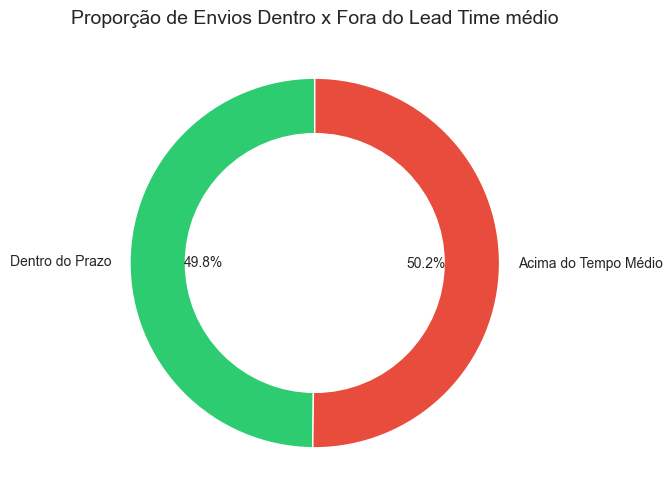

In [44]:
# Contagem de envios dentro e fora do prazo
contagem = df_logistic['fora_do_tempo_medio'].value_counts()

# Preparar dados
valores = [contagem[False], contagem[True]]
labels = ['Dentro do Prazo', 'Acima do Tempo Médio']
cores = ['#2ecc71', '#e74c3c']  # verde e vermelho

# Criar gráfico de rosca
plt.figure(figsize=(6,6))
plt.pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)

# Adicionar círculo branco no centro para efeito de rosca
centro = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro)

plt.title('Proporção de Envios Dentro x Fora do Lead Time médio', fontsize=14)
plt.show()


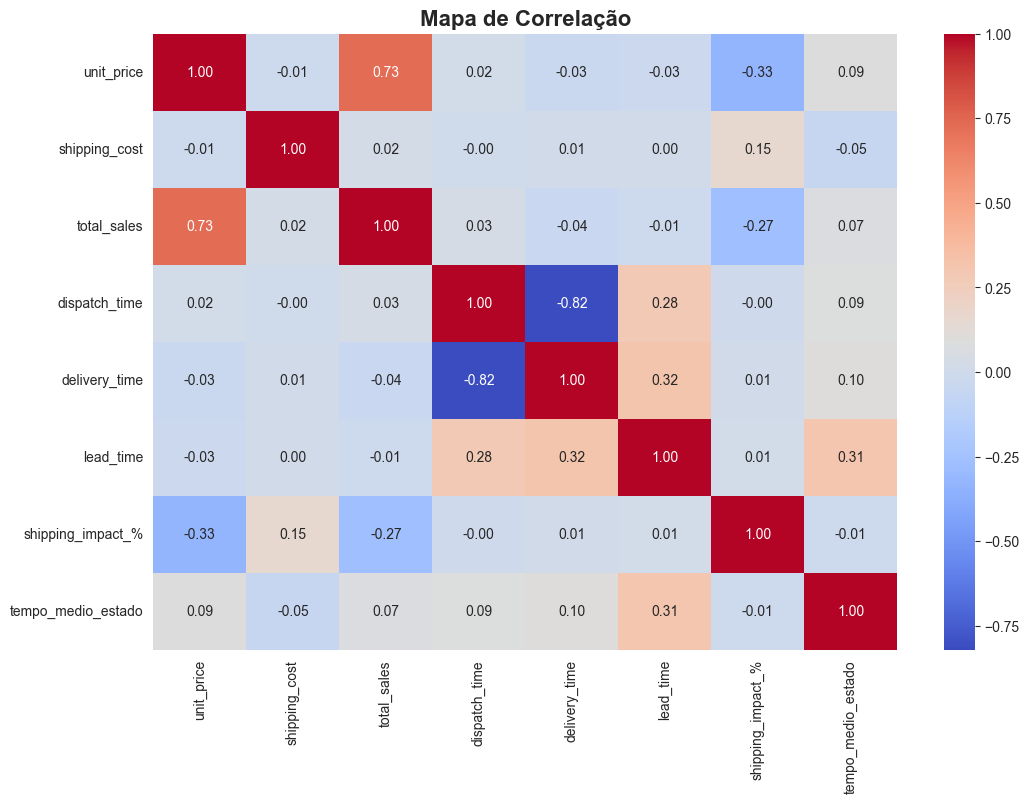

In [45]:
# Selecionar apenas colunas numéricas
df_corr = df_envios_fora_prazo.select_dtypes(include=['float64','int64'])

# Calcular correlação
corr_matrix = df_corr.corr()

# Plotar heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,        # mostra os valores dentro das células
    fmt=".2f",         # duas casas decimais
    cmap="coolwarm",   # paleta de cores
    cbar=True
)

plt.title("Mapa de Correlação", fontsize=16, fontweight='bold')
plt.show()


- Tempo de Despache x Tempo de Entrega 

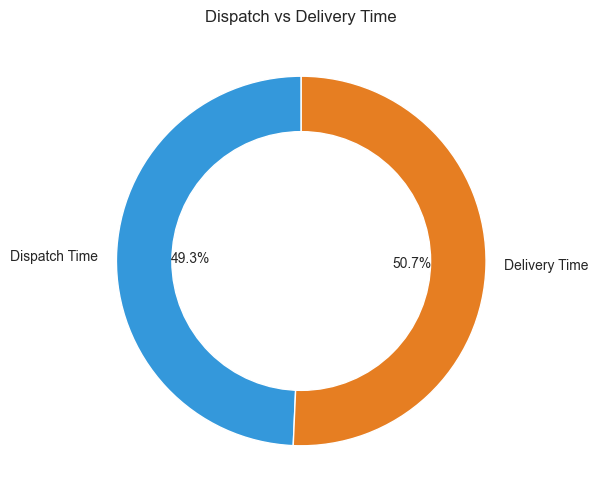

In [46]:
# Calcular médias
medias = {
    'Dispatch Time': df_logistic['dispatch_time'].mean(),
    'Delivery Time': df_logistic['delivery_time'].mean()
}

# Converter para porcentagem em relação ao total
total = sum(medias.values())
valores = [(v/total)*100 for v in medias.values()]
labels = medias.keys()
cores = ['#3498db','#e67e22']  # azul e laranja

# Criar gráfico de rosca
plt.figure(figsize=(6,6))
plt.pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)

# Adicionar círculo branco no centro
centro = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro)

plt.title('Dispatch vs Delivery Time')
plt.show()


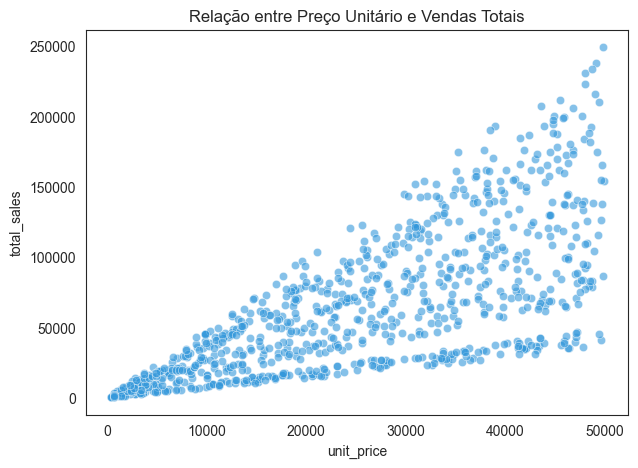

In [47]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_envios_fora_prazo,
    x='unit_price',
    y='total_sales',
    alpha=0.6,
    color='#3498db'
)
plt.title('Relação entre Preço Unitário e Vendas Totais')
plt.show()


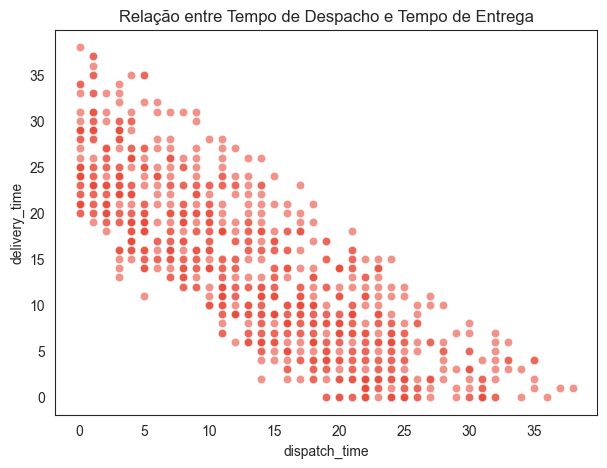

In [48]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_envios_fora_prazo,
    x='dispatch_time',
    y='delivery_time',
    alpha=0.6,
    color='#e74c3c'
)
plt.title('Relação entre Tempo de Despacho e Tempo de Entrega')
plt.show()


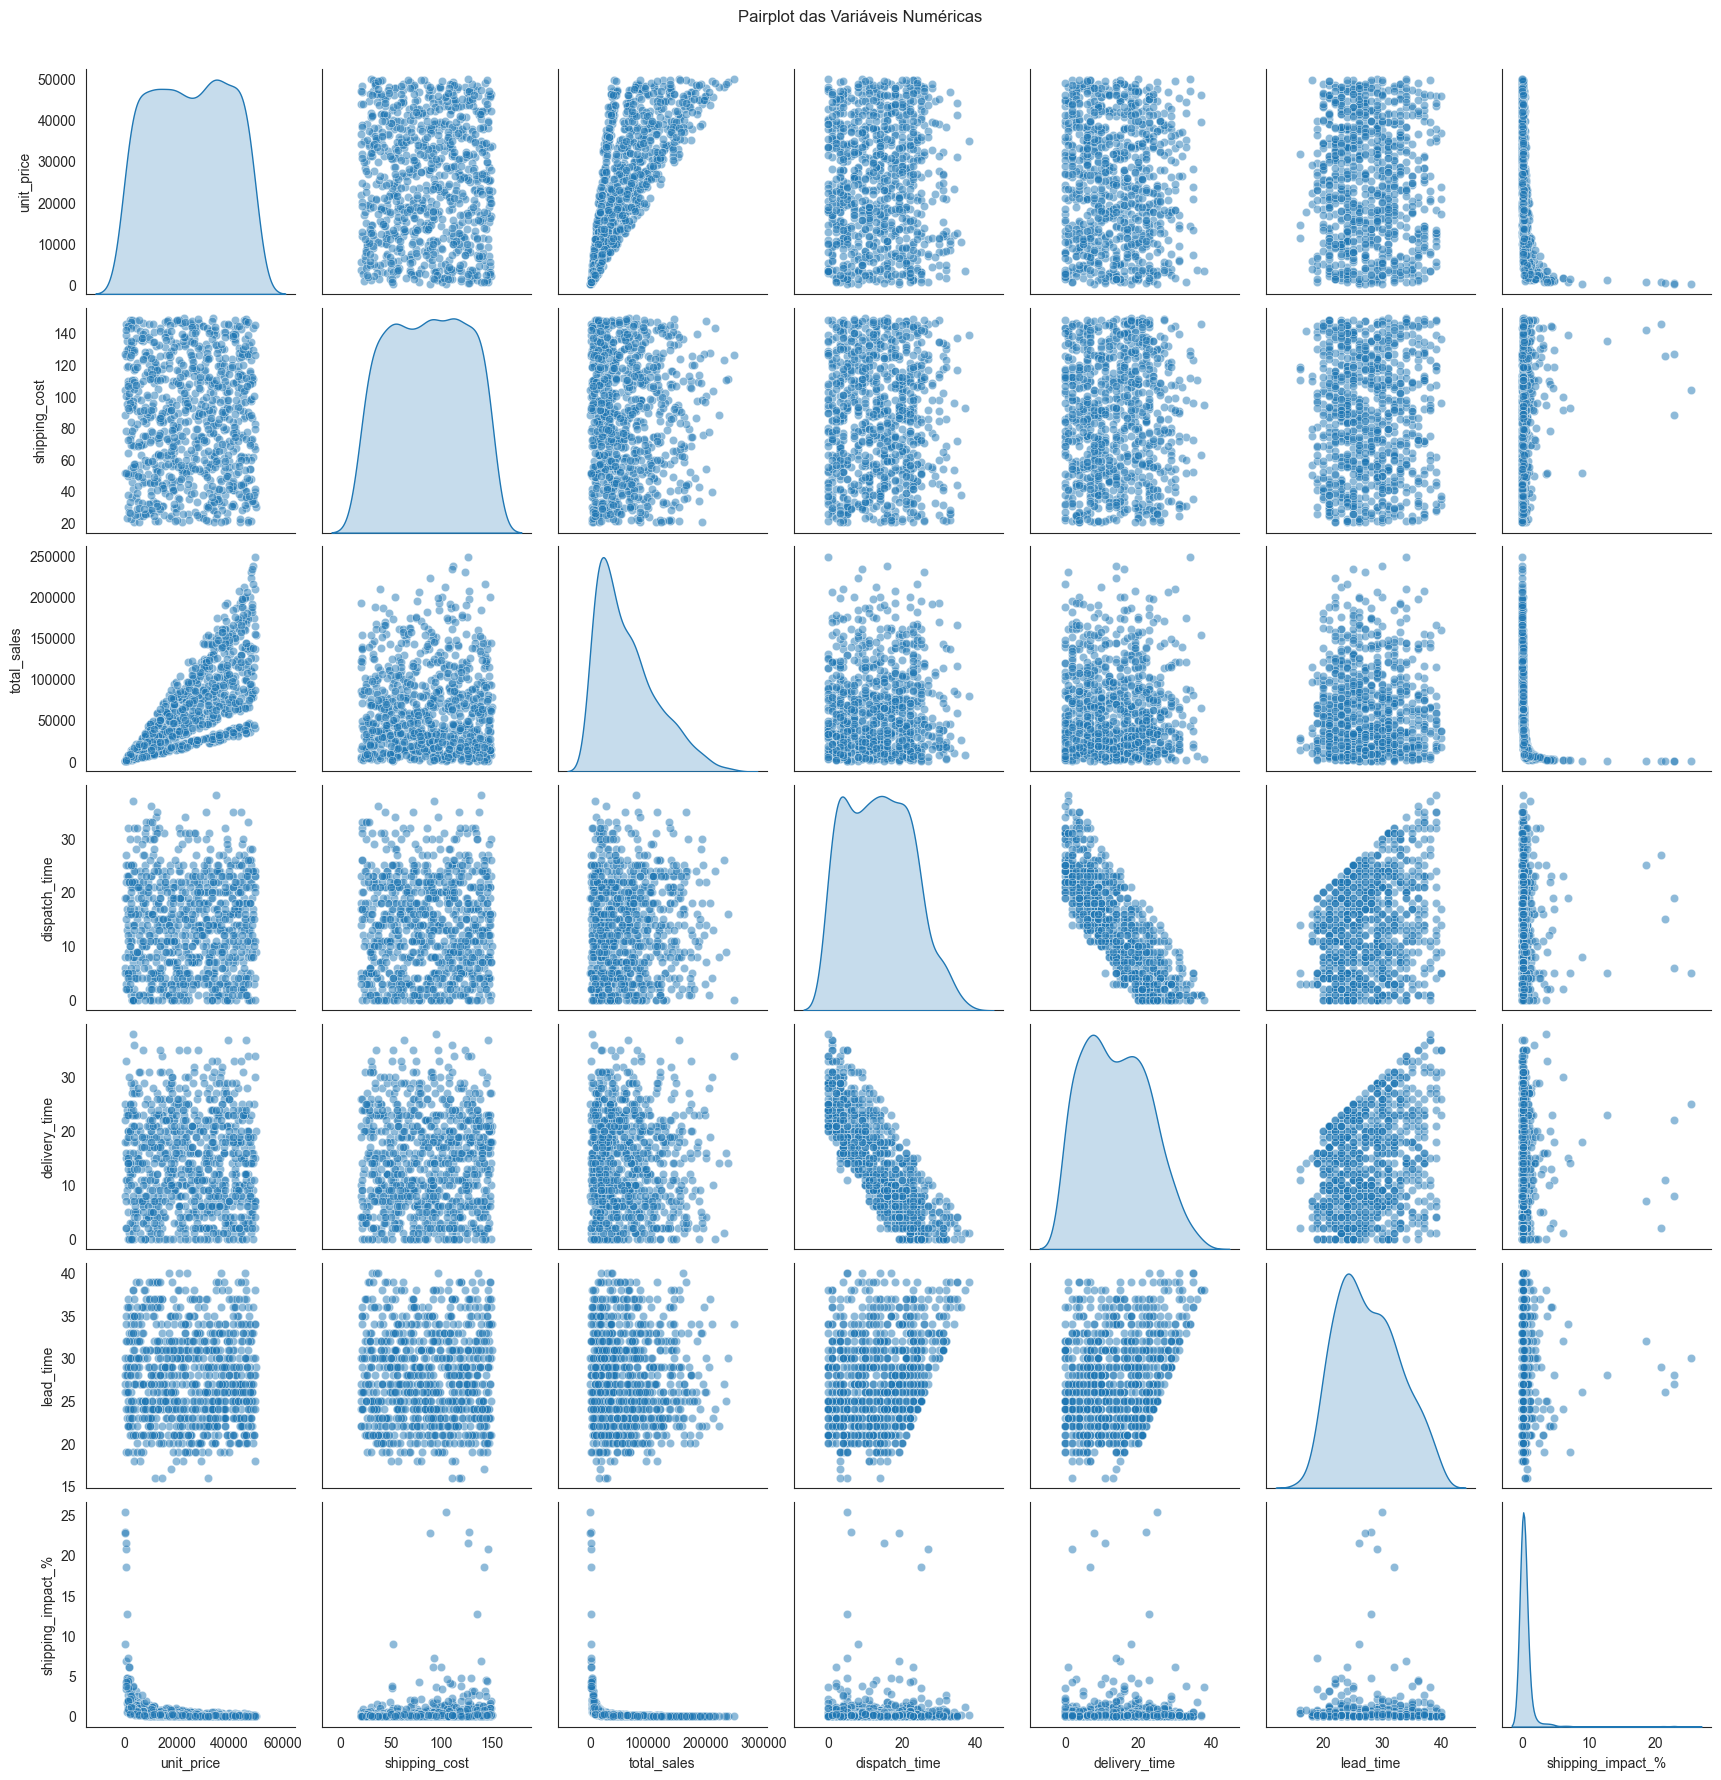

In [49]:
sns.pairplot(
    df_envios_fora_prazo[['unit_price','shipping_cost','total_sales',
                          'dispatch_time','delivery_time','lead_time','shipping_impact_%']],
    diag_kind='kde',
    plot_kws={'alpha':0.5}
)
plt.suptitle('Pairplot das Variáveis Numéricas', y=1.02)
plt.show()


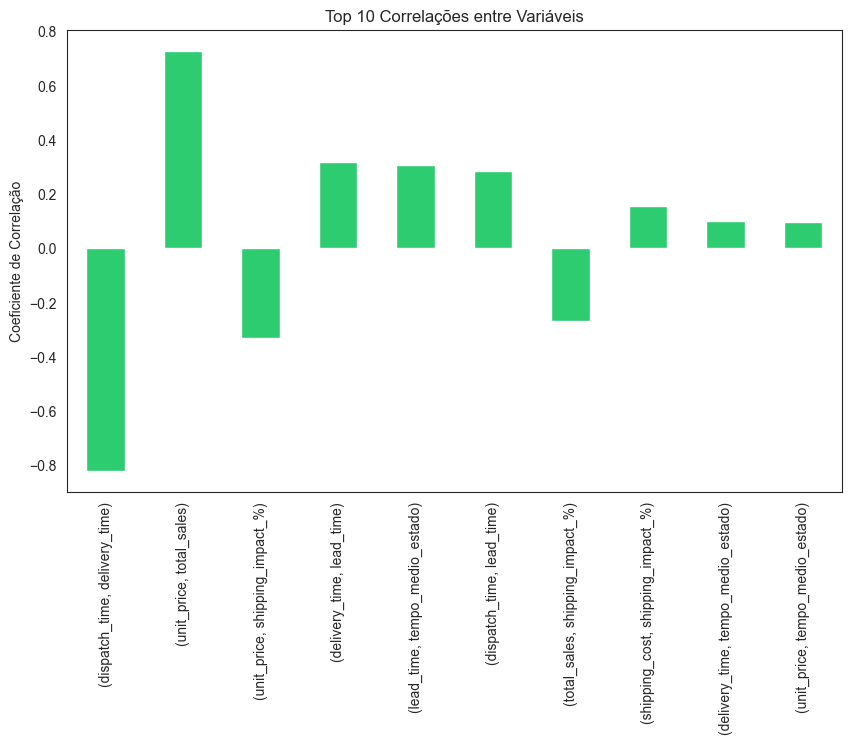

In [50]:
# Calcular correlação
corr_matrix = df_envios_fora_prazo.select_dtypes(include=['float64','int64']).corr()

# Selecionar pares mais fortes
corr_pairs = (
    corr_matrix.unstack()
    .drop_duplicates()
    .sort_values(key=lambda x: abs(x), ascending=False)
)

# Top 10 correlações
top_corr = corr_pairs[1:11]  # exclui a correlação perfeita (1.0)

plt.figure(figsize=(10,6))
top_corr.plot(kind='bar', color='#2ecc71')
plt.title('Top 10 Correlações entre Variáveis')
plt.ylabel('Coeficiente de Correlação')
plt.show()


**Conclusões:**
- Ao somar os 15% de desconto médio aos 20% de custo de frete, você está comprometendo 35% da receita bruta apenas com incentivo e transporte, sem contar o custo do produto. Algumas vendas em regiões distantes podem estar gerando prejuízo operacional.

- Preço unitário x Vendas totais  
Correlação forte e positiva (~0.73). Isso mostra que produtos com maior preço unitário tendem a gerar maior valor de vendas, o que é esperado.

- Tempo de despacho x Tempo de entrega  
Correlação negativa forte (~-0.82). Isso sugere que quando o despacho demora mais, a entrega tende a ser mais rápida (possivelmente porque o transporte é agilizado para compensar o atraso inicial). É um ponto curioso que pode indicar estratégias logísticas de correção.

**Insights:**

- Gestão de categorias de baixo valor: acessórios e itens baratos sofrem mais com o peso do frete. Estratégias como frete grátis ou subsídio podem ser necessárias para manter competitividade.

- Atenção ao despacho: atrasos no despacho parecem ser compensados por transporte mais rápido, mas isso pode gerar custos extras. Melhorar o tempo de preparação pode reduzir a necessidade de compensações.

- Diferenças regionais: estados com lead time médio elevado puxam os atrasos. Isso sugere que a logística regional (distância, infraestrutura) é um fator crítico.

- Frete não é o único vilão: a correlação fraca entre custo de frete e atraso mostra que atrasos estão mais ligados a processos internos (despacho e transporte) do que ao valor do frete em si.

### 3. Gráfico de Pareto

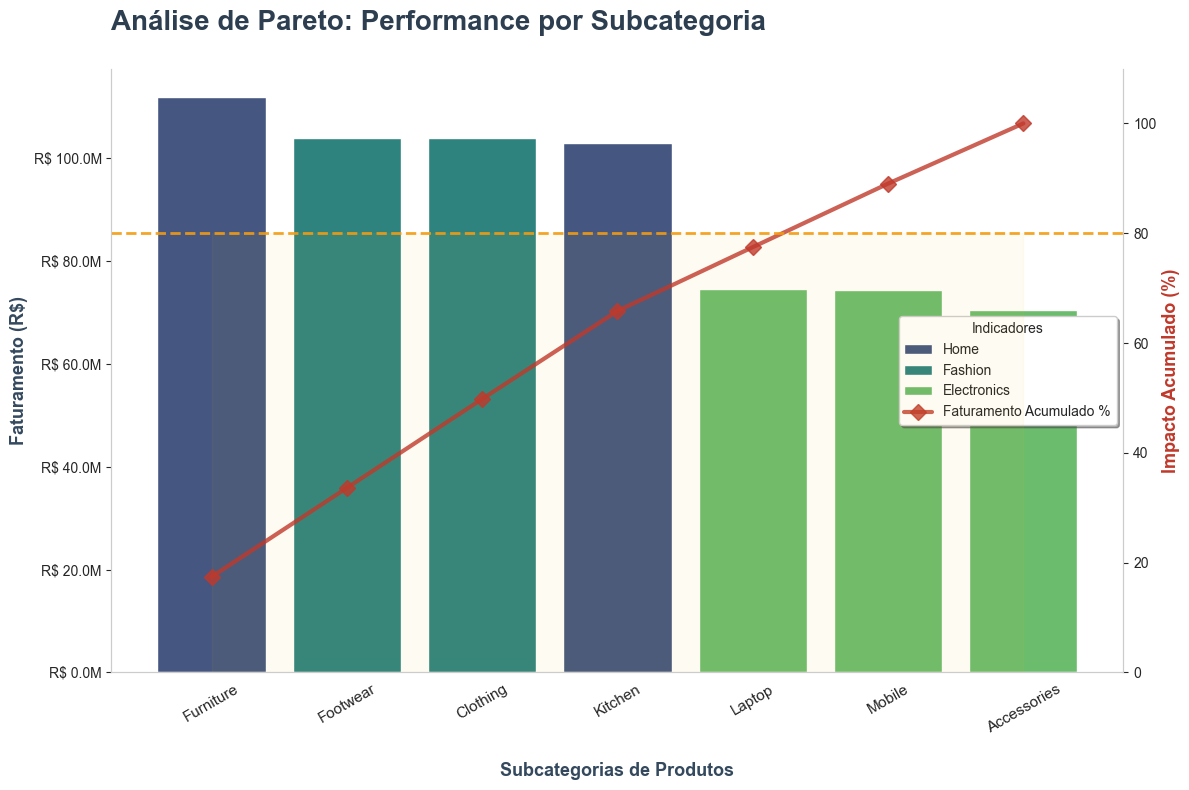

In [51]:
# 1. Preparação dos dados por Subcategoria
pareto_sub = df1.groupby(['sub_category', 'category'])['total_sales'].sum().sort_values(ascending=False).reset_index()
pareto_sub['cum_percent'] = (pareto_sub['total_sales'].cumsum() / pareto_sub['total_sales'].sum()) * 100

# 2. Configuração estética do Matplotlib
sns.set_style("whitegrid", {'axes.grid': False}) # Fundo limpo
fig, ax1 = plt.subplots(figsize=(12, 8))

# 3. Gráfico de Barras - Estilizado
# Usando a paleta 'mako' ou 'flare' para um ar mais moderno
barras = sns.barplot(
    data=pareto_sub, 
    x='sub_category', 
    y='total_sales', 
    hue='category', 
    ax=ax1, 
    dodge=False, 
    palette='viridis',
    edgecolor='white',
    linewidth=1
)

# 4. Linha de Pareto - Estilizada
ax2 = ax1.twinx()
ax2.plot(
    pareto_sub['sub_category'], 
    pareto_sub['cum_percent'], 
    color='#C0392B', # Vermelho elegante
    marker='D',      # Marcador em diamante
    markersize=8, 
    linewidth=3, 
    label='Faturamento Acumulado %',
    alpha=0.8
)

# 5. Destaque da Regra 80/20
ax2.axhline(80, color='#F39C12', linestyle='--', linewidth=2, alpha=0.9)
ax2.fill_between(pareto_sub['sub_category'], 0, 80, color='#F1C40F', alpha=0.05) # Área de destaque suave

# 6. Refinamento de Labels e Títulos
ax1.set_title('Análise de Pareto: Performance por Subcategoria\n', fontsize=20, fontweight='bold', loc='left', color='#2C3E50')
ax1.set_ylabel('Faturamento (R$)', fontsize=13, fontweight='semibold', color='#34495E')
ax1.set_xlabel('\nSubcategorias de Produtos', fontsize=13, fontweight='semibold', color='#34495E')
ax1.tick_params(axis='x', rotation=30, labelsize=11)

# Formatação do Eixo Y para Moeda (K para milhar, M para Milhão)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'R$ {x/1e6:,.1f}M'))
ax2.set_ylabel('Impacto Acumulado (%)', fontsize=13, fontweight='semibold', color='#C0392B')
ax2.set_ylim(0, 110)

# 7. Legendas Organizadas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right', title='Indicadores', frameon=True, shadow=True)

sns.despine(right=False, top=True) # Remove bordas desnecessárias
plt.tight_layout()
plt.show()